Профессия Data Science  
Блок 6. Математика в ML. Часть II  
**MATH&ML-10. Кластеризация и техники понижения размерности. Часть I**

---

## **✍ Оглавление:**
1. Введение
2. K-means
3. EM-алгоритм
4. K-Means и EM-алгоритм: практика
5. DBSCAN

## **1. Введение**

**Кластеризация** — это задача группировки объектов на подмножества (кластеры) таким образом, чтобы объекты из одного кластера были более похожи друг на друга, чем на объекты из других кластеров, по какому-либо критерию.

## **2. K-means**

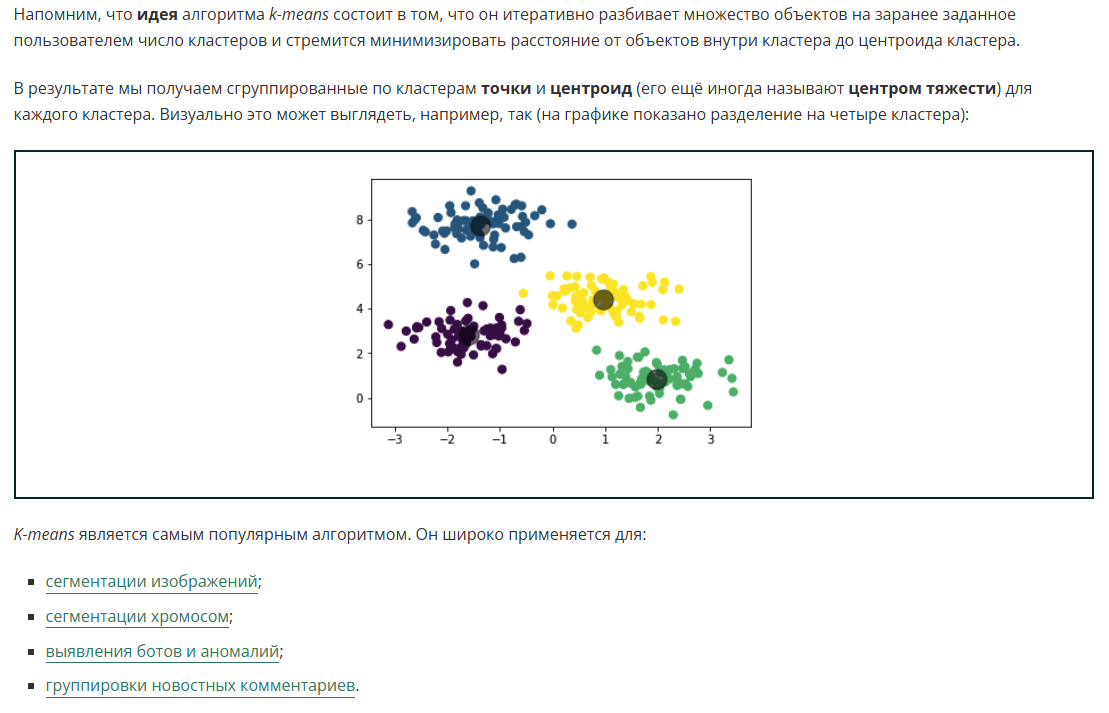

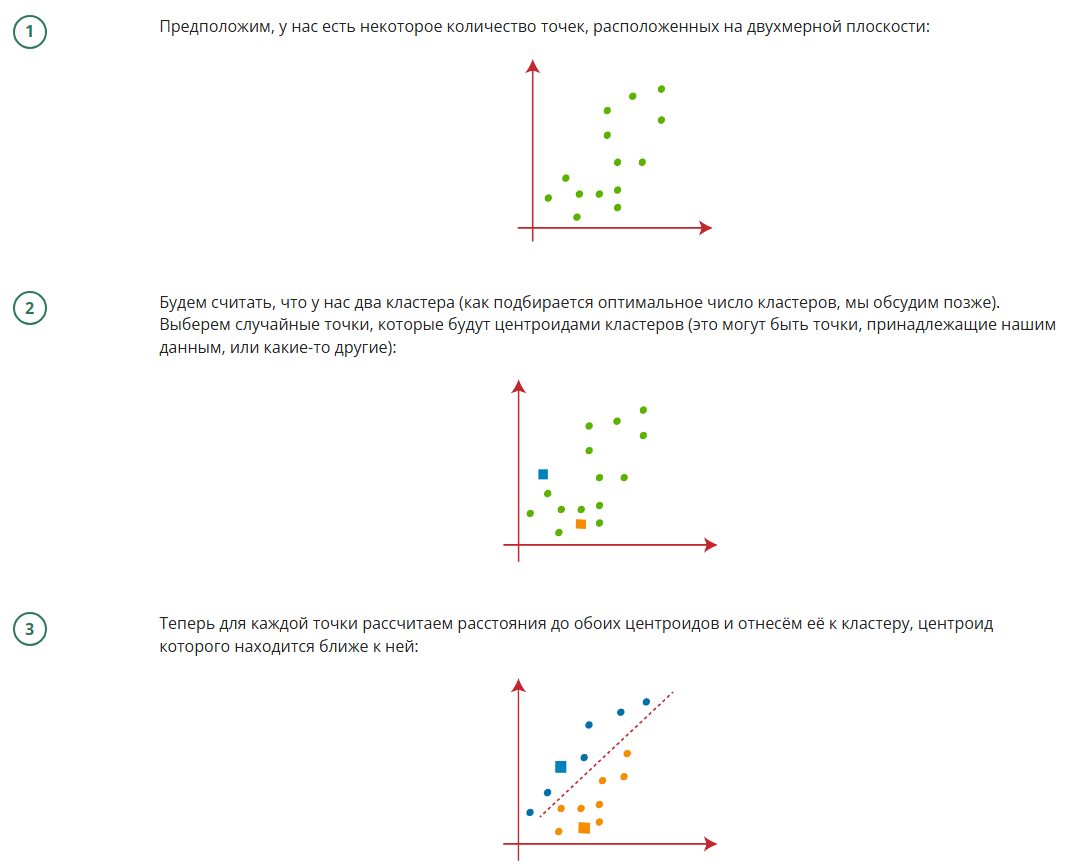

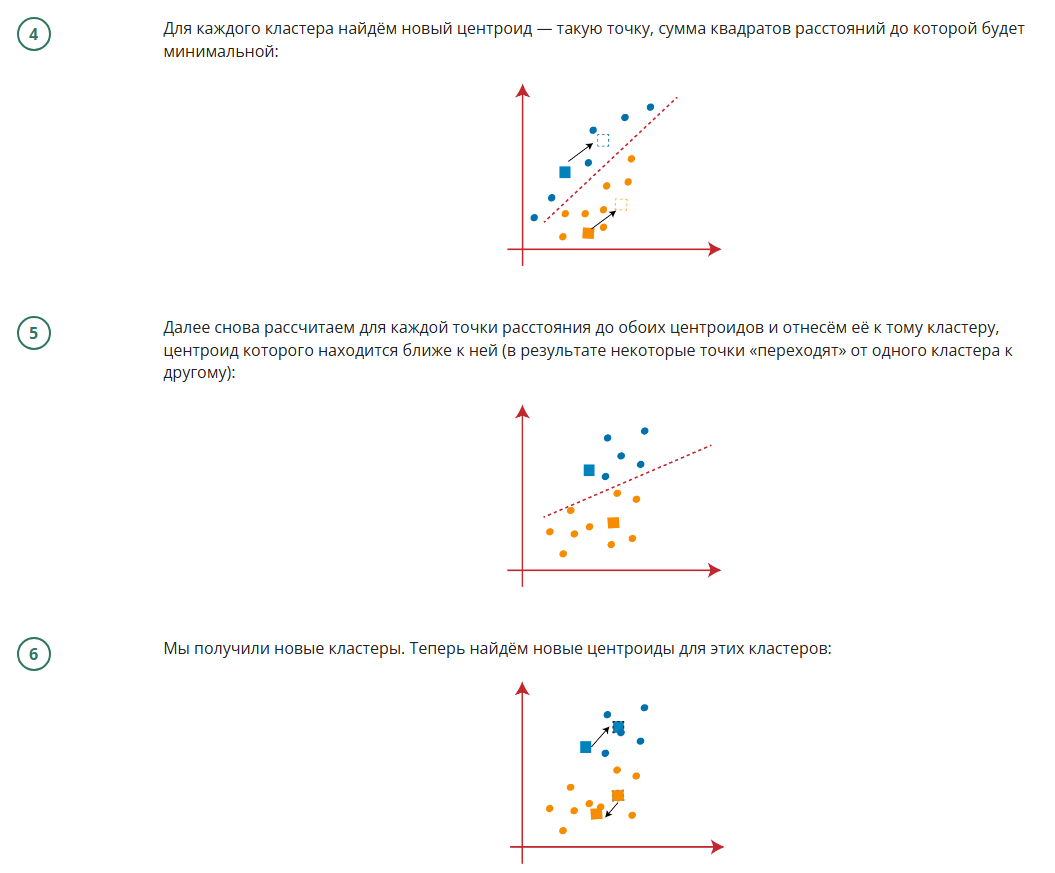

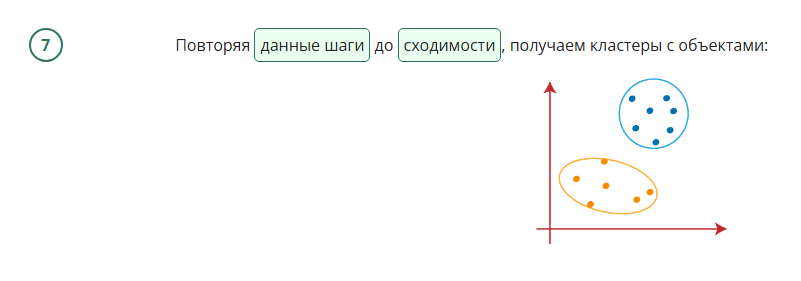

## **3. EM-алгоритм**

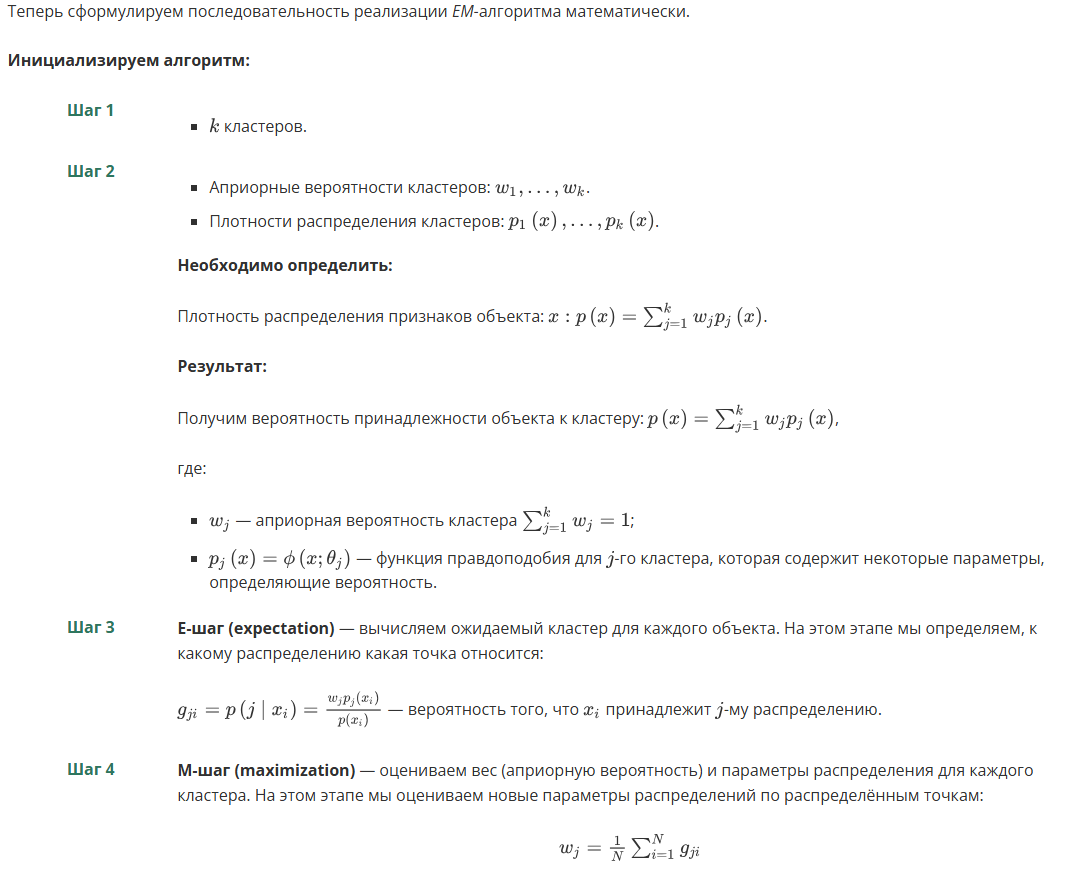

## **4. K-Means и EM-алгоритм: практика**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Загружаем исходные данные:
df_sns = pd.read_csv('snsdata.csv')
df_sns.head(3)

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [18]:
# Задание 4.1

df_sns = df_sns.iloc[:, 4:]
df_sns.shape

(30000, 36)

In [19]:
# Задание 4.2

X = df_sns.values
scaler = StandardScaler()
scaler.fit(X)
X_norm = scaler.transform(X)
X_norm[0][0]

-0.3322172643985876

In [25]:
# Задание 4.3

model = KMeans(n_clusters=9, random_state=42)
model.fit(X_norm)
model.inertia

AttributeError: 'KMeans' object has no attribute 'inertia'

In [22]:
# Задание 4.4

df_sns.loc[:, 'label'] = model.labels_
df_sns.label.value_counts()

label
1    19599
2     4284
0     2201
4      941
3      902
5      851
8      754
7      467
6        1
Name: count, dtype: int64

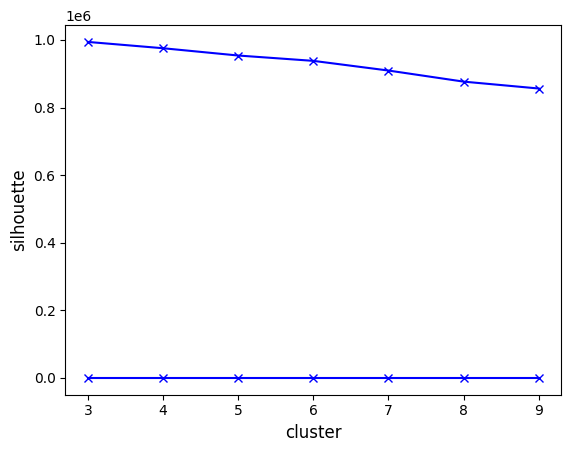

In [23]:
# Задание 4.5

def get_inertia(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    inertia = k_means.inertia_
    return inertia
 
inertia = []
for cluster_num in range(3, 10):
    inertia.append(get_inertia(cluster_num, X_norm))
 
plt.xlabel("cluster", fontsize=12)
plt.ylabel("inertia", fontsize=12)
plt.plot([i for i in range(3, 10)], inertia, 'xb-')
from sklearn.metrics import silhouette_score

def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_, metric='euclidean')
    return silhouette

silhouettes = []
for i in range(3, 10):
    silhouettes.append(get_silhouette(i, X_norm))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(3, 10)], silhouettes, 'xb-')

In [24]:
# Задание 4.6

top_list = []
for label, group in df.groupby('label'):
    means = group.iloc[:,:-1].mean().sort_values(ascending=False)
    top_5 = set(means.head(10).index)
    top_list.append(top_5)

set.intersection(*top_list)

KeyError: 'label'

In [28]:
# Задание 4.7

from sklearn.mixture import GaussianMixture
model = GaussianMixture(n_components=3, random_state=42)
predictions = model.fit_predict(X)
np.unique(predictions, return_counts=True)

(array([0, 1, 2], dtype=int64), array([21744,  5219,  3037], dtype=int64))

In [27]:
# Задание 4.8

a = np.where(predictions == 2)
df_sns.iloc[a]

NameError: name 'predictions' is not defined

## **5. DBSCAN**

Этот алгоритм хорошо подходит для ситуаций, когда необходимо выделить кластеры различной, порой довольно сложной формы. Такая задача достаточно часто возникает при анализе географических данных: например, при выделении кластеров пользователей по геометкам.

**Основная идея** этого алгоритма заключается в том, что объект  принадлежит кластеру, если находится достаточно близко ко многим объектам из этого кластера.

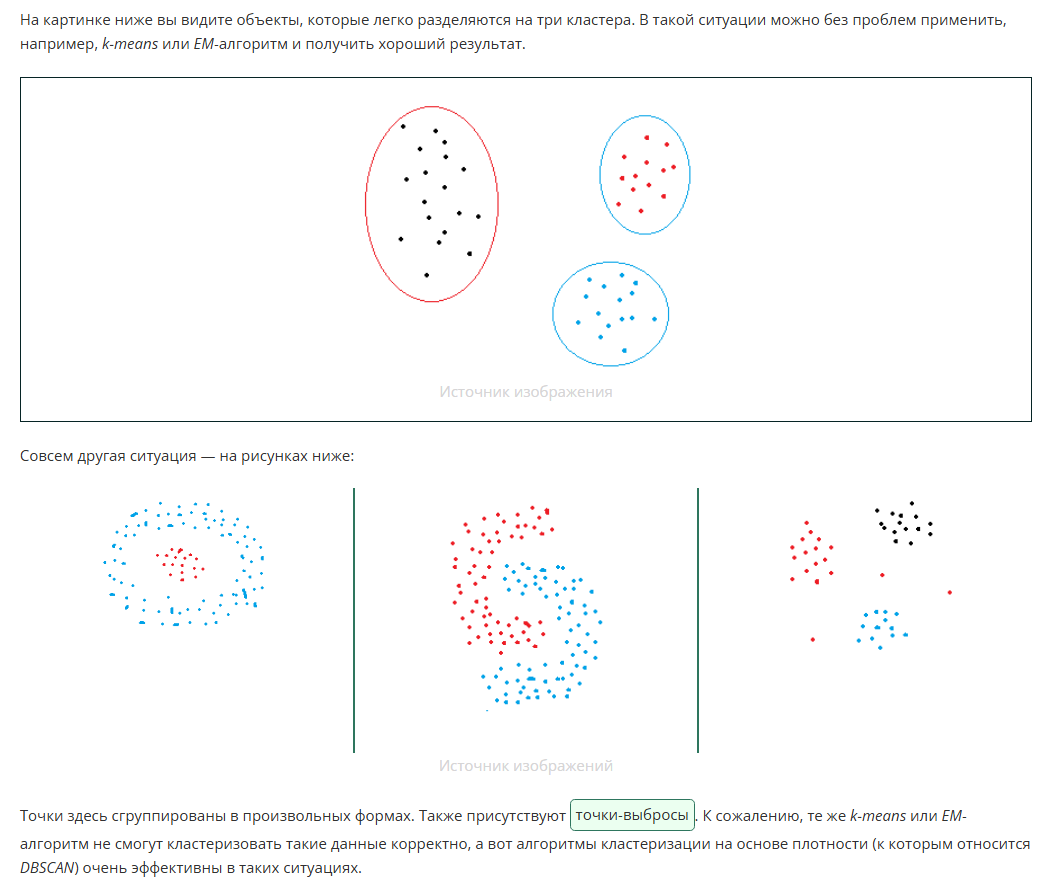

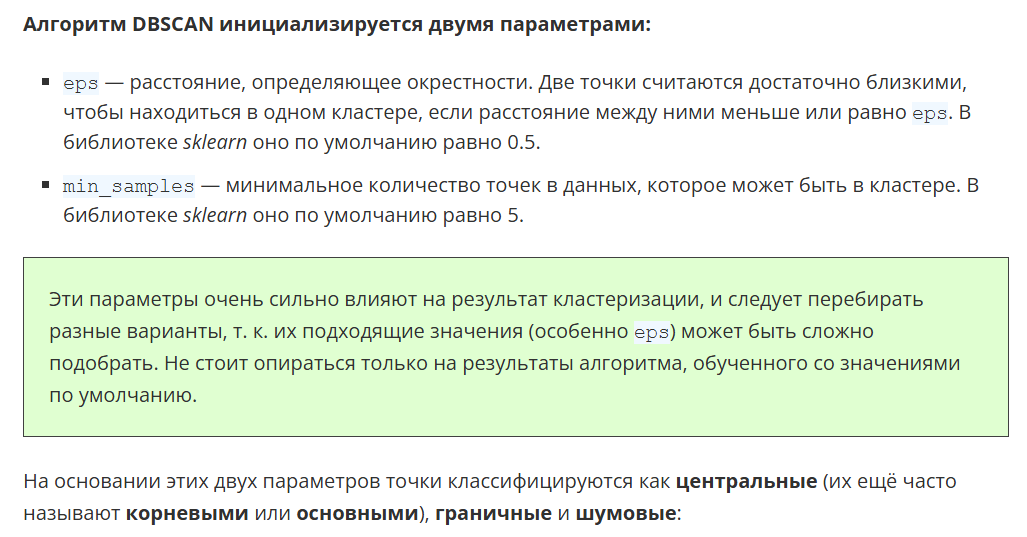

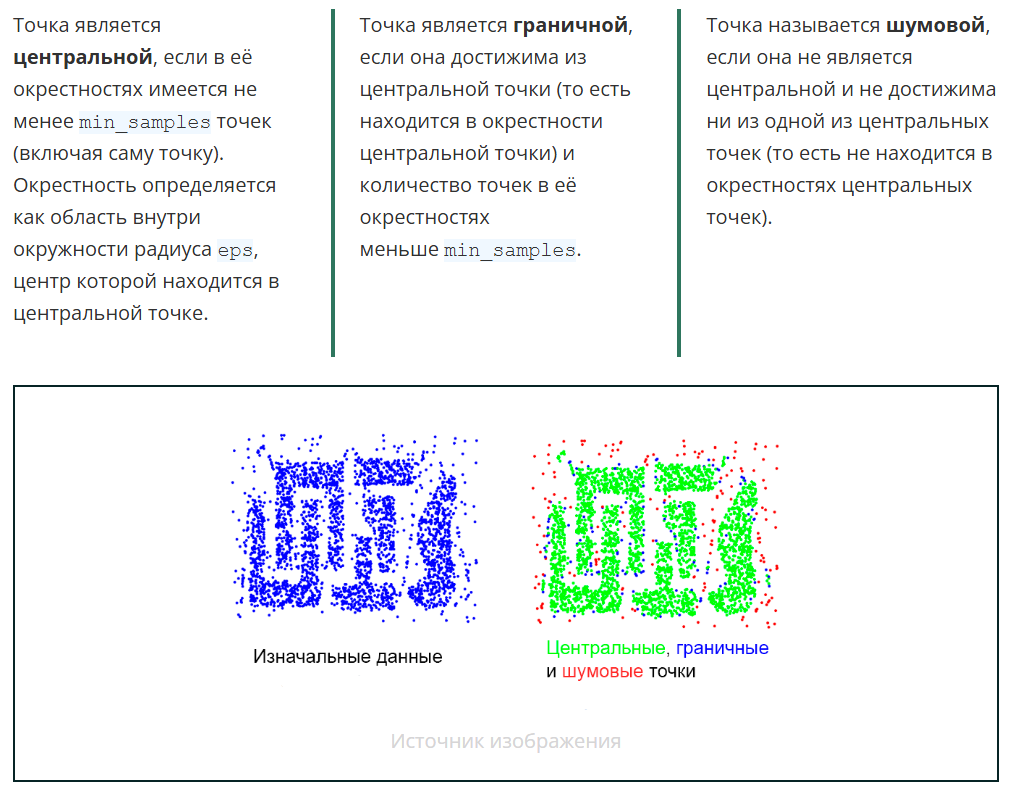

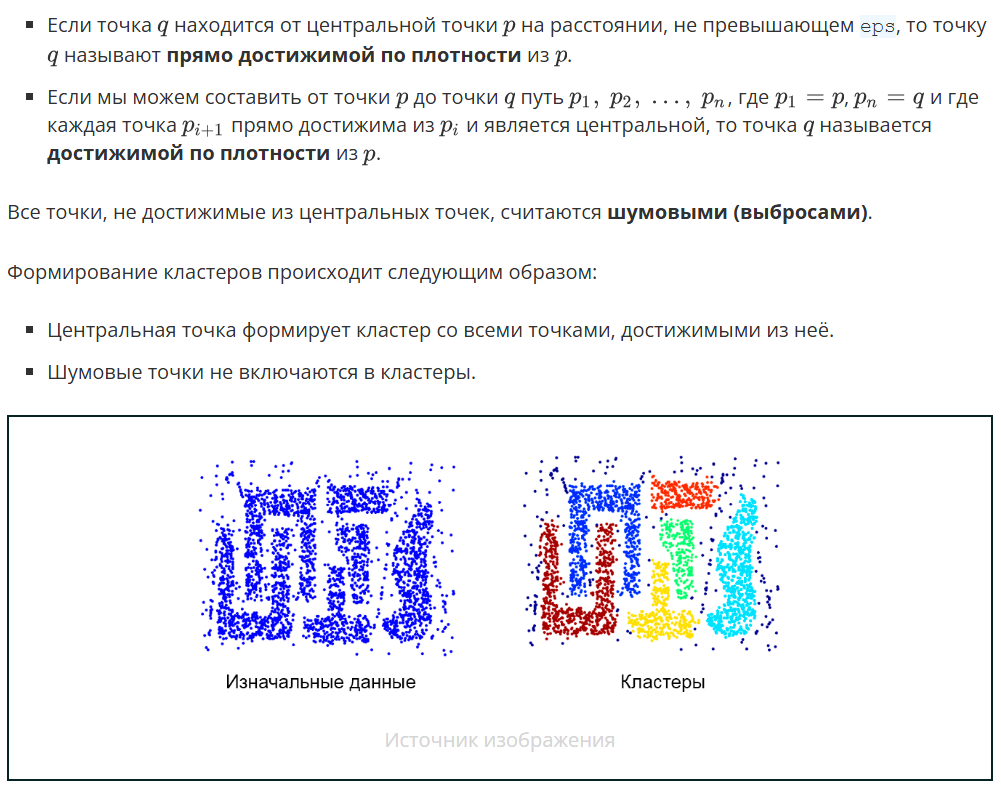

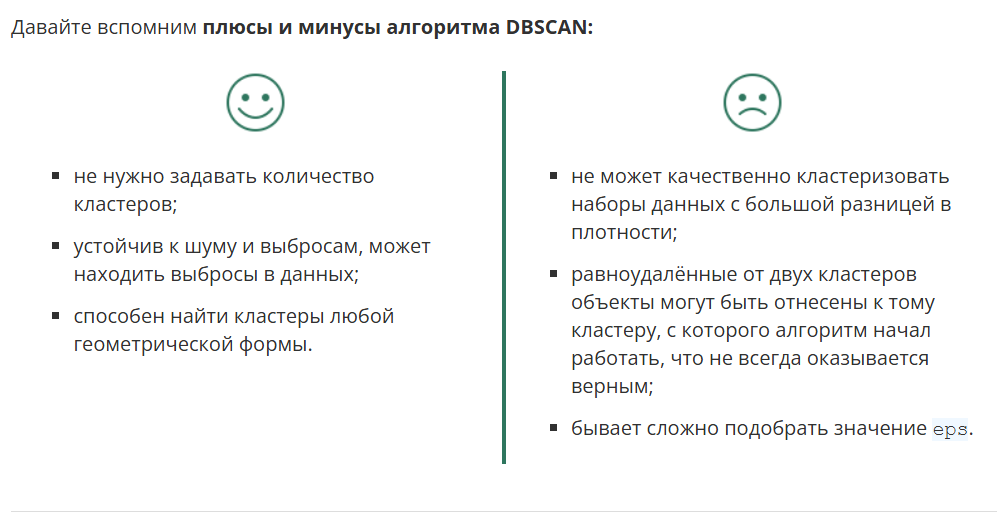

